In [ ]:
import pandas as pd
from transformers import pipeline
import torch

# 1. Initialize the Sentiment Pipeline
# This automatically downloads the distilbert-base-uncased-finetuned-sst-2-english model
device = 0 if torch.cuda.is_available() else -1
sentiment_model = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

def analyze_sentiment(text):
    """Classifies text and returns Label and Confidence Score."""
    try:
        # Truncate text to 512 tokens (DistilBERT limit)
        result = sentiment_model(str(text)[:512])[0]
        label = result['label']
        score = result['score']

        # Logic for Neutral: If confidence is too low, or score is near the middle
        # SST-2 is binary, so we interpret scores < 0.6 as potentially neutral
        if score < 0.60:
            return "NEUTRAL", score
        return label, score
    except Exception as e:
        return "ERROR", 0.0

# 2. Apply to your DataFrame
print("--- Starting Sentiment Analysis with DistilBERT ---")
# Using a progress bar or simple apply
df[['sentiment', 'confidence']] = df['review'].apply(
    lambda x: pd.Series(analyze_sentiment(x))
)

# 3. Quick Results Summary
print(df['sentiment'].value_counts())
display(df.head())

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1258.22it/s]


--- Starting Sentiment Analysis with DistilBERT ---


NameError: name 'df' is not defined

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Data Loaded: 11499 reviews found.


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2944.84it/s]


--- Running DistilBERT Inference (This may take a minute) ---


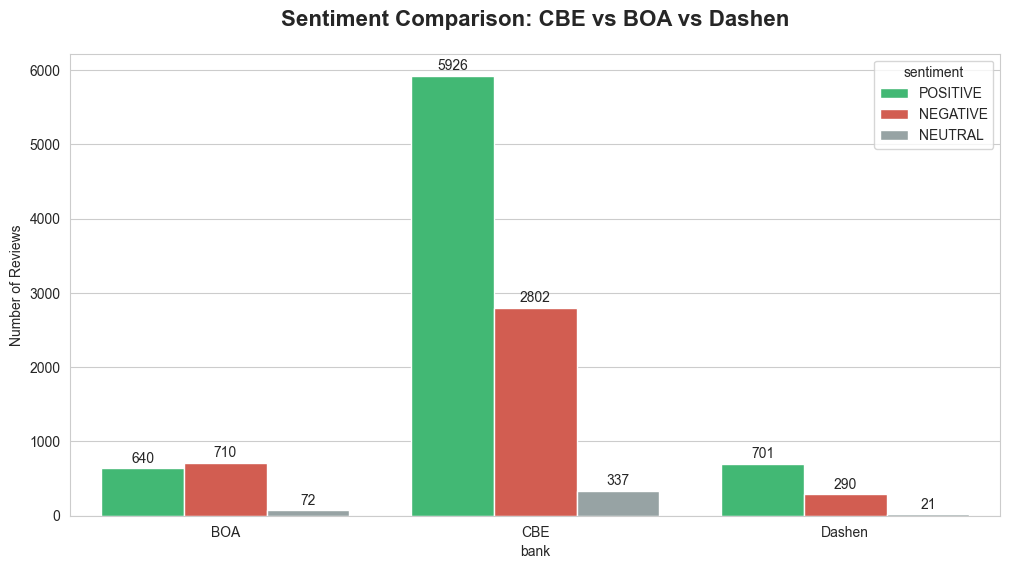

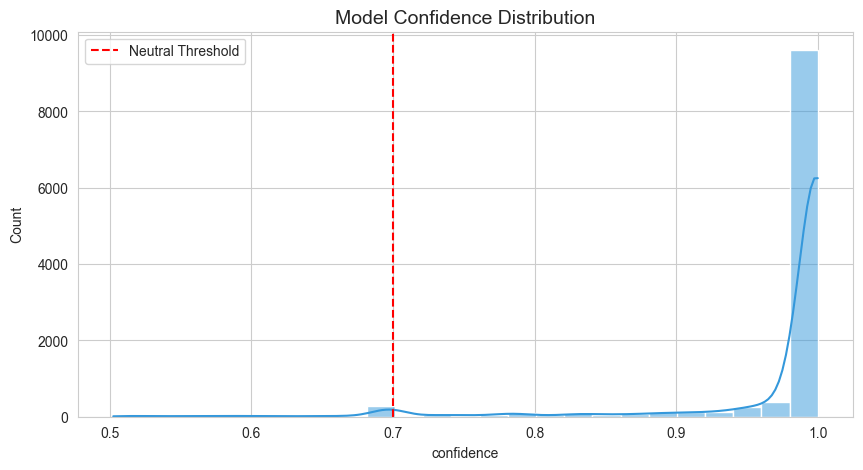

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from transformers import pipeline
import torch

# --- STEP 1: LOAD THE DATA (Fixes the NameError) ---
search_path = "../data/raw/*_reviews.csv"
all_files = glob.glob(search_path)
if not all_files:
    all_files = glob.glob("data/raw/*_reviews.csv")

if not all_files:
    print("❌ Error: No CSV files found. Run your scraper script first!")
else:
    # Load and combine all bank reviews
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    print(f"✅ Data Loaded: {len(df)} reviews found.")

    # --- STEP 2: SETUP DISTILBERT ---
    device = 0 if torch.cuda.is_available() else -1
    classifier = pipeline(
        "sentiment-analysis", 
        model="distilbert-base-uncased-finetuned-sst-2-english",
        device=device
    )

    def get_sentiment_data(text):
        try:
            # DistilBERT limit is 512 tokens
            result = classifier(str(text)[:512])[0]
            label = result['label']
            score = result['score']
            # Threshold for Neutral (SST-2 is binary, so we map middle-confidence)
            if score < 0.70:
                return "NEUTRAL", score
            return label, score
        except:
            return "ERROR", 0.0

    # --- STEP 3: RUN INFERENCE ---
    print("--- Running DistilBERT Inference (This may take a minute) ---")
    df[['sentiment', 'confidence']] = df['review'].apply(lambda x: pd.Series(get_sentiment_data(x)))

    # --- STEP 4: VISUALIZATION 1 (Sentiment by Bank) ---
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    palette_colors = {'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c', 'NEUTRAL': '#95a5a6'}
    
    ax = sns.countplot(x='bank', hue='sentiment', data=df, palette=palette_colors)
    plt.title('Sentiment Comparison: CBE vs BOA vs Dashen', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Number of Reviews')
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 7), textcoords='offset points')
    plt.show()

    # --- STEP 5: VISUALIZATION 2 (Confidence Histogram) ---
    plt.figure(figsize=(10, 5))
    sns.histplot(df['confidence'], bins=25, kde=True, color='#3498db')
    plt.title('Model Confidence Distribution', fontsize=14)
    plt.axvline(x=0.7, color='red', linestyle='--', label='Neutral Threshold')
    plt.legend()
    plt.show()